In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)

2026-05-15 12:26:33.026644: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-15 12:26:33.073001: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-15 12:26:34.283700: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-15 12:26:40.733340: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

In [2]:
import sys
# sys.path.append(r"E:\Python code\Machine learning\JupyterNote\Bio_CRC\Data processing\functions")
sys.path.append(r"/ihome/ylee/yiz133/Code/Data processing/functions/")
import mdata_utils 


In [6]:
path = r"/ix1/ylee/Yifan_Zhang/Code_data/Tumor/GSE139555_2019/data/Processed/"
mdata = mu.read(path + "GSE139555_Tcells.h5mu")

mdata.obs["subtype"] = mdata.obs["type"].astype(str) + "_" + mdata.obs["subtype"].astype(str)
mdata

MuData object with n_obs × n_vars = 111062 × 30727
  obs:	'isT', 'ident', 'patient', 'source', 'type', 'subtype', 'clone_loc'
  2 modalities
    gex:	111062 x 30727
      obs:	'sample'
    airr:	111062 x 0
      obs:	'sample'
      obsm:	'airr'

In [7]:
mdata.obs['source']

LT1_AAACCTGAGGATATAC-1    Tumor
LT1_AAACCTGAGTTACCCA-1    Tumor
LT1_AAACCTGCAACACCCG-1    Tumor
LT1_AAACCTGCATCTCCCA-1    Tumor
LT1_AAACCTGGTTCGTCTC-1    Tumor
                          ...  
RB3_TTTGGTTCAAGGTTTC-1    Blood
RB3_TTTGGTTCATCAGTCA-1    Blood
RB3_TTTGGTTTCAACACCA-1    Blood
RB3_TTTGTCACACAGGCCT-1    Blood
RB3_TTTGTCATCACGACTA-1    Blood
Name: source, Length: 111062, dtype: category
Categories (3, object): ['Blood', 'NAT', 'Tumor']

## QC

In [10]:
mdata['gex'].var["mt"] = mdata['gex'].var_names.str.startswith("MT-")
# ribosomal genes
mdata['gex'].var["ribo"] = mdata['gex'].var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
mdata['gex'].var["hb"] = mdata['gex'].var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(
    mdata['gex'], qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)
# 

sc.pp.filter_cells(mdata['gex'], min_genes= 100)
sc.pp.filter_cells(mdata['gex'], max_genes= 5000)

sc.pp.filter_cells(mdata['gex'], min_counts=500)
sc.pp.filter_cells(mdata['gex'], max_counts=20000)

sc.pp.filter_genes(mdata['gex'], min_cells=50)

sc.pp.normalize_total(mdata['gex'])
sc.pp.log1p(mdata['gex'])

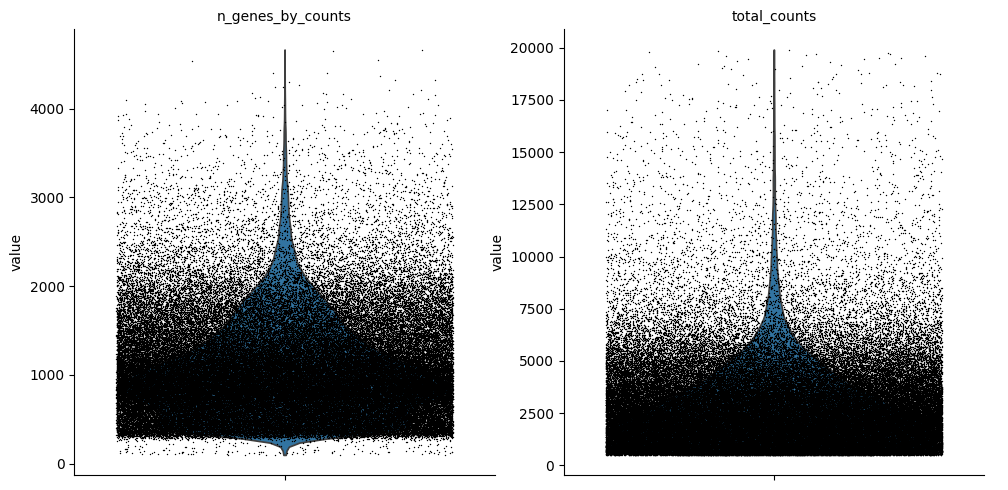

In [11]:
sc.pl.violin(
    mdata['gex'],
    ["n_genes_by_counts", "total_counts"],
    jitter=0.4,
    multi_panel=True,
)

In [14]:
ribo_genes = [g for g in mdata['gex'].var_names if g.startswith(("RPS", "RPL", "MRPS", "MRPL"))]
mito_genes = [g for g in mdata['gex'].var_names if g.startswith("MT-")]
tcr_noise = [g for g in mdata['gex'].var_names if g.startswith(("TRAV", "TRBV", "TRAJ", "TRBJ", "TRAC", "TRBC", "TRDV", "TRGV"))]

# stress_genes = ["HSPA1A", "HSPA1B", "HSPH1", "DNAJB1",
#                 "FOS", "JUN", "JUNB", "EGR1", "DUSP1",
#                 "ZFP36", "ATF3", "NR4A1", "NR4A2"]
# FOS/JUN family especially common artifacts in T cell DEG lists
mt_explicit = [
    "ATP6", "ATP8",      # ATP synthase
    "COX1", "COX2", "COX3",   # cytochrome c oxidase
    "ND1", "ND2", "ND3", "ND4", "ND4L", "ND5", "ND6",  # NADH dehydrogenase
    "CYB",               # cytochrome b
    "RNR1", "RNR2",      # mitochondrial rRNA
]
noise_mt = [g for g in mdata['gex'].var_names if g in mt_explicit]

noise_genes = set(
    ribo_genes +
    mito_genes +
    tcr_noise + noise_mt)

In [15]:
mdata.update()
mdata

MuData object with n_obs × n_vars = 111062 × 15436
  obs:	'isT', 'ident', 'patient', 'source', 'type', 'subtype', 'clone_loc'
  2 modalities
    gex:	105582 x 15436
      obs:	'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
      uns:	'log1p'
    airr:	111062 x 0
      obs:	'sample'
      obsm:	'airr'

In [16]:
mdata['gex'].var_names_make_unique()
TCR_gene_mask = mdata['gex'].var_names.isin(noise_genes)
mdata = mdata[:, ~TCR_gene_mask]

In [17]:
mdata

View of MuData object with n_obs × n_vars = 111062 × 15219
  obs:	'isT', 'ident', 'patient', 'source', 'type', 'subtype', 'clone_loc'
  2 modalities
    gex:	105582 x 15219
      obs:	'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
      uns:	'log1p'
    airr:	111062 x 0
      obs:	'sample'
      obsm:	'airr'

## Preprocessing

In [18]:
mdata_ori = mdata.copy()
mdata = mdata_utils.sync_mdata_obs(mdata)
mdata

MuData object with n_obs × n_vars = 105582 × 15219
  obs:	'isT', 'ident', 'patient', 'source', 'type', 'subtype', 'clone_loc'
  2 modalities
    gex:	105582 x 15219
      obs:	'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
      uns:	'log1p'
    airr:	105582 x 0
      obs:	'sample'
      obsm:	'airr'

In [19]:
mdata['gex'].obs['patient'] = mdata.obs['patient']
mdata['gex'].obs['source'] = mdata.obs['source']
mdata['gex'].obs['type'] = mdata.obs['type']
mdata['gex'].obs['subtype'] = mdata.obs['subtype']

In [20]:
# Select HVG in total

# sc.pp.highly_variable_genes(mdata['gex'], n_top_genes=5000, batch_key="patient")
# mdata.mod['gex'] = mdata['gex'][:, mdata['gex'].var['highly_variable']].copy()
# mdata.update()

# mdata = mdata[mdata.obs['type'].isin(['CD8'])].copy()
# mdata = mdata_utils.sync_mdata_obs(mdata)

### Select HVG per sample

In [21]:
# Compute top-k HVGs per COMBAT_ID on GEX, then replace GEX matrix with HVG-only genes.

K_HVG = 200
GROUP_KEY = "sample"
MIN_CELLS_PER_GROUP = 50

gex = mdata.mod["gex"]
if gex.n_vars == 0:
    raise RuntimeError("mdata.mod['gex'] has 0 genes. Reload raw mdata before HVG selection.")
if GROUP_KEY not in gex.obs.columns:
    raise KeyError(f"{GROUP_KEY!r} not found in mdata.mod['gex'].obs")

genes_union: set[str] = set()
skipped: list[tuple[object, str]] = []
counts = gex.obs[GROUP_KEY].value_counts(dropna=True)

for gid, n in counts.items():
    if n < MIN_CELLS_PER_GROUP:
        skipped.append((gid, f"only {n} cells (< {MIN_CELLS_PER_GROUP})"))
        continue

    sub = gex[gex.obs[GROUP_KEY] == gid].copy()
    sub = sub[:, sub.var_names.notna()].copy()
    # try:
    
    sc.pp.highly_variable_genes(
        sub,
        n_top_genes=min(K_HVG, sub.n_vars),
        inplace=True,
        # flavor='seurat_v3',   # use raw count
    )
    # except Exception as exc:  # noqa: BLE001
    #     skipped.append((gid, repr(exc)))
    #     continue

    hv = sub.var["highly_variable"].fillna(False).to_numpy(dtype=bool)
    genes_union.update(sub.var_names[hv].astype(str))

hvg_union = sorted(genes_union)
if len(hvg_union) == 0:
    raise RuntimeError("HVG union is empty. Check skipped errors above.")

mask = np.isin(gex.var_names.astype(str), hvg_union)
selected = gex.var_names[mask]

gex.var["hvg_union_COMBAT_ID"] = mask
gex.uns["hvg_union_COMBAT_ID_k200"] = hvg_union
gex.uns["hvg_union_COMBAT_ID_meta"] = {
    "group_key": GROUP_KEY,
    "k_per_group": K_HVG,
    "min_cells_per_group": MIN_CELLS_PER_GROUP,
    "flavor": "scanpy_default",
    "layer": "scanpy_default",
    "n_groups": int(len(counts)),
    "n_union_genes": int(len(hvg_union)),
}

gex_hvg = gex[:, selected].copy()
gex_hvg.var["hvg_union_COMBAT_ID"] = True
gex_hvg.uns["hvg_union_COMBAT_ID_k200"] = hvg_union
gex_hvg.uns["hvg_union_COMBAT_ID_meta"] = dict(gex.uns["hvg_union_COMBAT_ID_meta"])

mdata.mod["gex"] = gex_hvg
mdata.uns["hvg_union_COMBAT_ID_meta"] = dict(gex_hvg.uns["hvg_union_COMBAT_ID_meta"])

print(f"Selected HVG union genes: {len(hvg_union):,}")
print(f"New GEX shape: {mdata.mod['gex'].n_obs:,} cells x {mdata.mod['gex'].n_vars:,} genes")
print("GEX n_vars equals union size:", mdata.mod["gex"].n_vars == len(hvg_union))
if skipped:
    print(f"Skipped {len(skipped)} groups (showing up to 8):", skipped[:8])

Selected HVG union genes: 2,551
New GEX shape: 105,582 cells x 2,551 genes
GEX n_vars equals union size: True
Skipped 1 groups (showing up to 8): [('GSM4143671_SAM24350753-en2', 'only 16 cells (< 50)')]


In [22]:
sc.pp.scale(mdata['gex'], max_value=10)

In [23]:
sc.pp.pca(mdata["gex"], svd_solver="arpack", n_comps=50)
sc.pp.neighbors(mdata["gex"], n_neighbors = 50)
sc.tl.umap(mdata["gex"], min_dist=0.5, spread=1.0)
# sc.tl.leiden(mdata["gex"], resolution = 1, n_iterations=-1, flavor = 'igraph')

## Batch correction

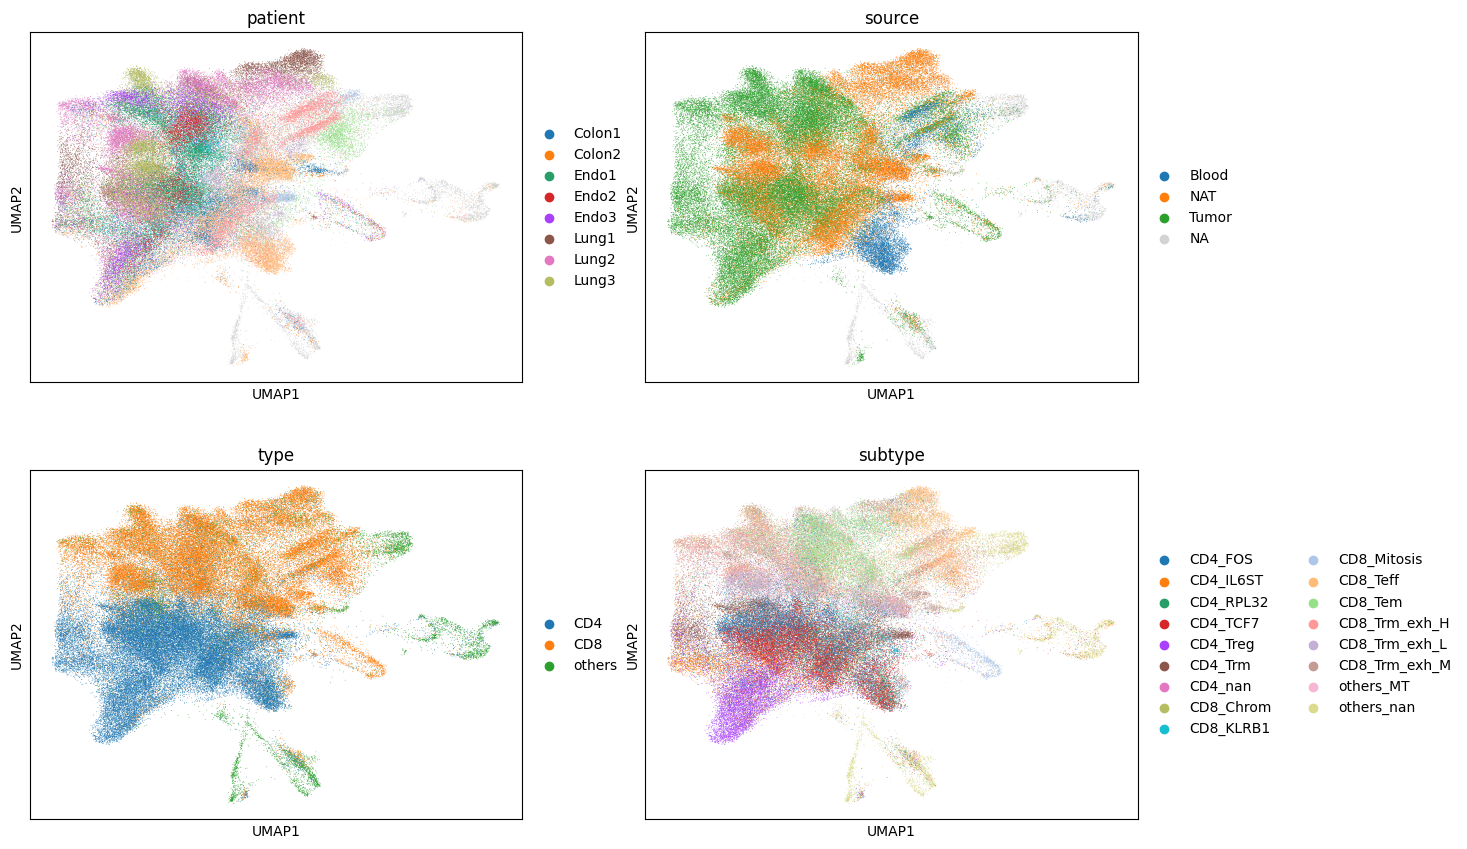

In [24]:
sc.pl.umap(mdata["gex"], color=["patient", "source", 'type','subtype'], ncols=2)

In [58]:
import scanpy.external as sce
sce.pp.harmony_integrate(mdata["gex"], key=['patient'],  basis='X_pca', max_iter_harmony=20, 
                          # theta = 4, lamb = 1.5, sigma=0.1, tau=1
                        )

2026-05-15 14:32:47,208 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-05-15 14:32:50,086 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-05-15 14:32:50,178 - harmonypy - INFO - Iteration 1 of 20
2026-05-15 14:32:56,191 - harmonypy - INFO - Iteration 2 of 20
2026-05-15 14:33:02,229 - harmonypy - INFO - Converged after 2 iterations


In [60]:
mdata

MuData object with n_obs × n_vars = 52533 × 2551
  obs:	'isT', 'ident', 'patient', 'source', 'type', 'subtype', 'clone_loc', 'unique_clone_id', 'cloned'
  uns:	'hvg_union_COMBAT_ID_meta'
  2 modalities
    gex:	52533 x 2551
      obs:	'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'patient', 'source', 'type', 'subtype'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'hvg_union_COMBAT_ID', 'mean', 'std'
      uns:	'log1p', 'hvg_union_COMBAT_ID_k200', 'hvg_union_COMBAT_ID_meta', 'pca', 'neighbors', 'umap', 'patient_colors', 'source_colors', 'type_colors', 'subtype_colors', 'neighbors_harmony', 'X_umap_harmony'
      obsm:	'X_pca', 'X_umap', 'X_pca_harmony', 'X_umap_harmony'
      varm:	'PCs'
      obsp:	'distances', 'connectivities', 'neighbors_harmony_distances', 'neighbors_harmony_connectivities'
    airr:	52533 x 0
      obs:	'sample', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'cc_aa_tcrdist', 'cc_aa_tcrdist_size', 'clonal_expansion'
      uns:	'chain_indices', 'ir_dist_aa_identity', 'ir_dist_nt_identity', 'clone_id', 'ir_dist_aa_tcrdist', 'cc_aa_tcrdist'
      obsm:	'airr', 'chain_indices'

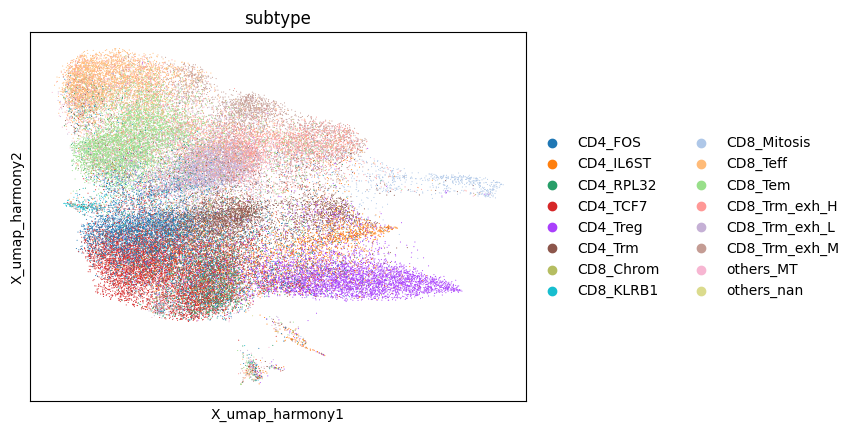

In [61]:
sc.pp.neighbors(mdata["gex"], n_neighbors = 20, use_rep='X_pca_harmony', key_added = 'neighbors_harmony')
sc.tl.umap(mdata["gex"], min_dist=0.5, spread=1.0, neighbors_key = 'neighbors_harmony', key_added = 'X_umap_harmony')
sc.pl.embedding(mdata["gex"], basis = 'X_umap_harmony', neighbors_key = 'neighbors_harmony', 
                color=['subtype'], ncols=2,)

# TCR

In [62]:
ir.pp.index_chains(mdata)
ir.tl.chain_qc(mdata)
mdata.update()
mdata

MuData object with n_obs × n_vars = 52533 × 2551
  obs:	'isT', 'ident', 'patient', 'source', 'type', 'subtype', 'clone_loc', 'unique_clone_id', 'cloned'
  uns:	'hvg_union_COMBAT_ID_meta'
  2 modalities
    gex:	52533 x 2551
      obs:	'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'patient', 'source', 'type', 'subtype'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'hvg_union_COMBAT_ID', 'mean', 'std'
      uns:	'log1p', 'hvg_union_COMBAT_ID_k200', 'hvg_union_COMBAT_ID_meta', 'pca', 'neighbors', 'umap', 'patient_colors', 'source_colors', 'type_colors', 'subtype_colors', 'neighbors_harmony', 'X_umap_harmony'
      obsm:	'X_pca', 'X_umap', 'X_pca_harmony', 'X_umap_harmony'
      varm:	'PCs'
      obsp:	'distances', 'connectivities', 'neighbors_harmony_distances', 'neighbors_harmony_connectivities'
    airr:	52533 x 0
      obs:	'sample', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'cc_aa_tcrdist', 'cc_aa_tcrdist_size', 'clonal_expansion'
      uns:	'chain_indices', 'ir_dist_aa_identity', 'ir_dist_nt_identity', 'clone_id', 'ir_dist_aa_tcrdist', 'cc_aa_tcrdist'
      obsm:	'airr', 'chain_indices'

In [63]:
mdata['airr'].obs['chain_pairing'].value_counts()

chain_pairing
single pair    52533
Name: count, dtype: int64

In [64]:
mdata = mdata[mdata['airr'].obs['chain_pairing'].isin(['single pair'])].copy()

In [65]:
ir.pp.ir_dist(mdata, sequence='aa')
ir.tl.define_clonotypes(mdata, receptor_arms="all", 
                        dual_ir="primary_only", 
                        within_group="patient",
                        same_v_gene=True,
                        same_j_gene=True)


In [66]:
mdata.obs['unique_clone_id'] = mdata.obs['patient'].astype('str') +'_'+ mdata['airr'].obs['clone_id'].astype('str')

In [67]:
mdata[mdata.obs['patient']== 'Renal3']['airr'].obs['clone_id']

RT3_AAAGCAAAGATATACG-1    27653
RT3_AAATGCCAGACTCGGA-1    27654
RT3_AACCATGTCGTCGTTC-1    27655
RT3_AACTCAGCAGTTTACG-1    27656
RT3_AACTGGTGTAGCGTCC-1    27657
                          ...  
RB3_TTGACTTTCTATCCTA-1    28465
RB3_TTGTAGGAGGTGCACA-1    27722
RB3_TTTACTGGTAAGGATT-1    28466
RB3_TTTATGCAGTTTGCGT-1    28467
RB3_TTTGGTTTCAACACCA-1    28468
Name: clone_id, Length: 1331, dtype: object

In [68]:
ir.pp.ir_dist(
    mdata,
    metric="tcrdist",
    sequence="aa",
    cutoff=15,
)
ir.tl.define_clonotype_clusters(mdata, sequence="aa", metric="tcrdist", 
                                receptor_arms="all", 
                                dual_ir="primary_only",
                                )
# within_group="patient"
ir.tl.clonal_expansion(mdata)

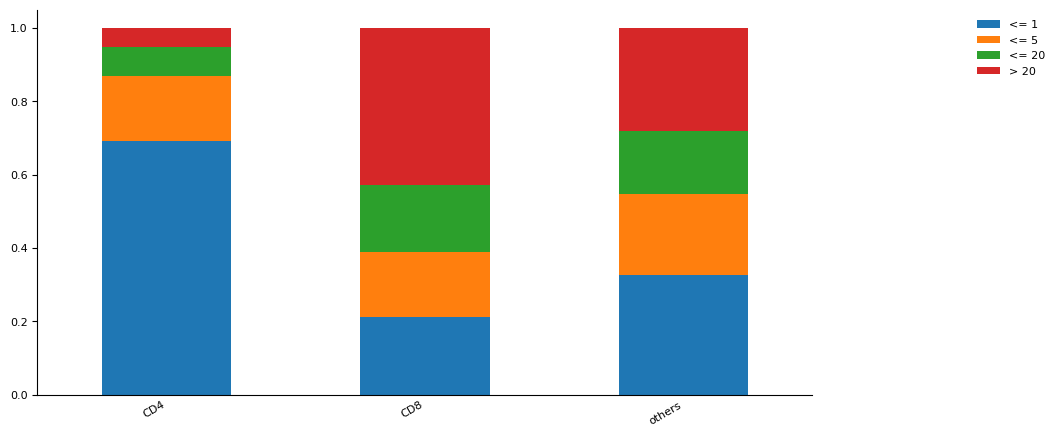

In [69]:
fig, ax = plt.subplots(figsize=(10, 5))
_ = ir.pl.clonal_expansion(
    mdata, 
    target_col= "airr:clone_id",
    groupby= "type",  # Use the new combined column
    breakpoints=(1, 5, 20), 
    ax = ax
    #normalize=False
)

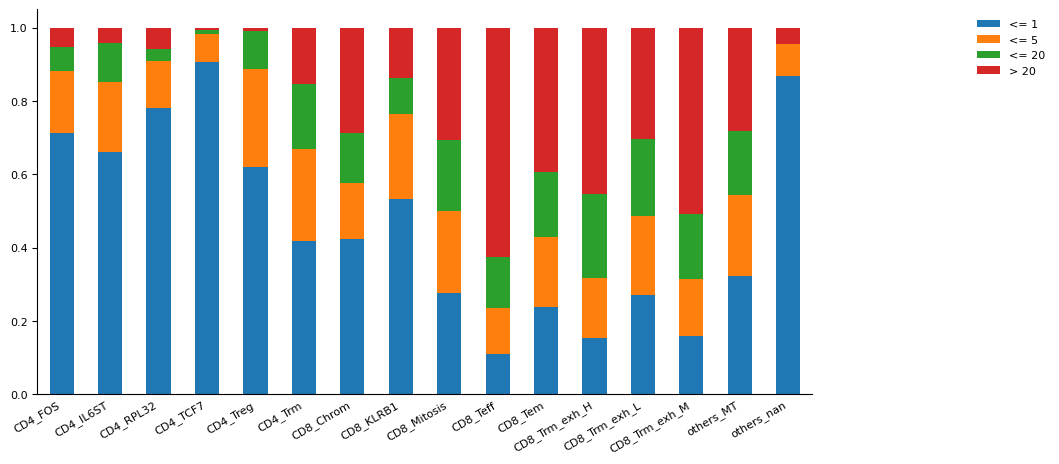

In [70]:
fig, ax = plt.subplots(figsize=(10, 5))
_ = ir.pl.clonal_expansion(
    mdata, 
    target_col= "airr:clone_id",
    groupby= "subtype",  # Use the new combined column
    breakpoints=(1, 5, 20), 
    ax = ax
    #normalize=False
)

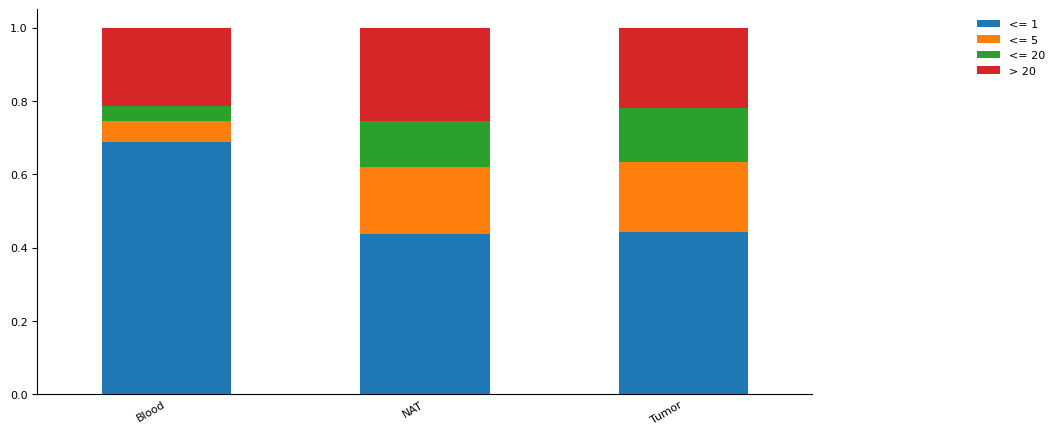

In [71]:
fig, ax = plt.subplots(figsize=(10, 5))
_ = ir.pl.clonal_expansion(
    mdata, 
    target_col= "airr:clone_id",
    groupby= "source",  # Use the new combined column
    breakpoints=(1, 5, 20), 
    ax = ax
    #normalize=False
)

In [72]:
clone_thresh = 2
mdata.obs['cloned'] = mdata['airr'].obs['clone_id_size'] >= clone_thresh
mdata.obs['cloned'].value_counts()


cloned
True     28524
False    24009
Name: count, dtype: int64

In [74]:
# Check if appear in two tissues
mdata_cloned = mdata[mdata.obs['cloned']]
clone_tissue_df = mdata_cloned['airr'].obs[['clone_id']].join(mdata_cloned['gex'].obs['source'])
clone_tissue_counts = clone_tissue_df.groupby('clone_id')['source'].nunique()
multi_tissue_clones = clone_tissue_counts[clone_tissue_counts > 1].index
mdata.obs['in_two_tissue'] = mdata['airr'].obs['clone_id'].isin(multi_tissue_clones)

mdata.obs['in_two_tissue'].value_counts()

in_two_tissue
False    36413
True     16120
Name: count, dtype: int64

In [75]:
mdata.obs['clone_status'] = np.select(
    [
        mdata.obs['cloned'] == False,
        mdata.obs['in_two_tissue'] == True,
        (mdata.obs['cloned'] == True) & (mdata.obs['in_two_tissue'] == False)
    ],
    [
        'single',
        'multiSite_clone',
        'singleSite_clone'
    ],
    default = 'nan'
)

mdata.obs['clone_status'] = mdata.obs['source'].astype(str) + '_' + mdata.obs['clone_status'].astype(str)

mdata.obs['clone_status'].value_counts()

clone_status
Tumor_single              12219
NAT_single                 9269
Tumor_singleSite_clone     8214
NAT_multiSite_clone        7773
Tumor_multiSite_clone      7253
NAT_singleSite_clone       4139
Blood_single               2521
Blood_multiSite_clone      1094
Blood_singleSite_clone       51
Name: count, dtype: int64

In [76]:
mdata['gex'].obs['clone_status'] = mdata.obs['clone_status']

# TCR embedings

In [77]:
import TCR_embedings

In [78]:
meta_airr = ir.get.airr(mdata['airr'], ["cdr3_aa", "v_call", "j_call"] ,  ('VJ_1', 'VDJ_1'))
mdata.obs = mdata.obs.join(meta_airr)
mdata.update()
mdata

MuData object with n_obs × n_vars = 52533 × 2551
  obs:	'isT', 'ident', 'patient', 'source', 'type', 'subtype', 'clone_loc', 'unique_clone_id', 'cloned', 'in_two_tissue', 'clone_status', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call'
  uns:	'hvg_union_COMBAT_ID_meta'
  2 modalities
    gex:	52533 x 2551
      obs:	'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'patient', 'source', 'type', 'subtype', 'clone_status'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'hvg_union_COMBAT_ID', 'mean', 'std'
      uns:	'log1p', 'hvg_union_COMBAT_ID_k200', 'hvg_union_COMBAT_ID_meta', 'pca', 'neighbors', 'umap', 'patient_colors', 'source_colors', 'type_colors', 'subtype_colors', 'neighbors_harmony', 'X_umap_harmony'
      obsm:	'X_pca', 'X_umap', 'X_pca_harmony', 'X_umap_harmony'
      varm:	'PCs'
      obsp:	'distances', 'connectivities', 'neighbors_harmony_distances', 'neighbors_harmony_connectivities'
    airr:	52533 x 0
      obs:	'sample', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'cc_aa_tcrdist', 'cc_aa_tcrdist_size', 'clonal_expansion'
      uns:	'chain_indices', 'ir_dist_aa_identity', 'ir_dist_nt_identity', 'clone_id', 'ir_dist_aa_tcrdist', 'cc_aa_tcrdist'
      obsm:	'airr', 'chain_indices'

In [79]:
obs = mdata.obs.copy()

n_alpha = obs['VJ_1_cdr3_aa'].nunique()
n_beta  = obs['VDJ_1_cdr3_aa'].nunique()

print(f"Unique alpha-chain (VJ) clonotypes:  {n_alpha}")
print(f"Unique beta-chain  (VDJ) clonotypes: {n_beta}")
print(f"Total cells: {len(obs)}")

Unique alpha-chain (VJ) clonotypes:  24798
Unique beta-chain  (VDJ) clonotypes: 26769
Total cells: 52533


In [80]:
# Atchley factors for the 20 amino acids
atchley_factors = {
    'A': [ 0.591, -1.302, -0.733,  1.570, -0.146],  # Alanine
    'R': [ 1.538,  0.055,  1.502,  0.440,  2.897],  # Arginine
    'N': [ 0.945,  0.828,  1.299, -0.169,  0.933],  # Asparagine
    'D': [ 1.050,  0.302, -3.656, -0.259, -3.242],  # Aspartic acid
    'C': [-1.343,  0.465, -0.862, -1.020, -0.255],  # Cysteine
    'Q': [ 0.931,  0.179, -3.005, -0.503, -1.853],  # Glutamine
    'E': [ 1.357,  0.113, -3.242, -0.339, -2.192],  # Glutamic acid
    'G': [ 0.384,  1.652,  1.330,  1.045,  2.064],  # Glycine
    'H': [ 0.336, -0.417, -1.673, -1.474, -0.078],  # Histidine
    'I': [-1.239, -0.547,  2.131,  0.393,  0.816],  # Isoleucine
    'L': [-1.019, -0.987, -1.505,  1.266, -0.912],  # Leucine
    'K': [ 1.831, -0.561,  0.533, -0.277,  1.648],  # Lysine
    'M': [-0.663, -1.524,  2.219, -1.005,  1.212],  # Methionine
    'F': [-1.006, -0.590,  1.891, -0.397,  0.412],  # Phenylalanine
    'P': [ 0.189,  2.081, -1.628,  0.421, -1.392],  # Proline
    'S': [ 0.228,  1.399, -4.760,  0.670, -2.647],  # Serine
    'T': [ 0.032,  2.213, -1.455,  0.311, -0.259],  # Threonine
    'W': [-0.595,  0.009,  0.672, -2.128, -0.184],  # Tryptophan
    'Y': [ 0.260,  0.830,  3.097, -0.838,  1.512],  # Tyrosine
    'V': [-1.337, -0.279, -0.544,  1.242, -1.262],  # Valine
}

In [81]:
# both chains
tcr_aa_obs = ['VDJ_1_cdr3_aa', 'VJ_1_cdr3_aa']
tcr_cat_features = ['VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call']

tcr_num_features = []

In [82]:
# Vectorize each TCR amino acid column and compute composition & length
for aa_col in tcr_aa_obs:
    # 1. Sequence length
    # Only keep cells with both alpha and beta chains
    lengths = TCR_embedings.compute_sequence_lengths(mdata, aa_col)
    lengths_mask = (lengths> 5) & (lengths< 20)
    len_key = f'{aa_col}_length'
    mdata = mdata[lengths_mask]
    mdata.obs[len_key] = lengths[lengths_mask]
    print(f"Stored {aa_col} lengths in mdata.obs['{len_key}']")
    
    # 2. Atchley factor encoding
    encoded = TCR_embedings.vectorize_tcr_column(mdata, aa_col, atchley_factors)
    key_name = f'X_{aa_col}_atchley'
    mdata.obsm[key_name] = encoded
    print(f"Stored {aa_col} Atchley vectors in mdata.obsm['{key_name}'] with shape {encoded.shape}")
    
    # 2b. Adjacent Atchley factor interactions
    # atchley_positions = encoded.shape[1] // 5
    # pairwise_key = f'X_{aa_col}_atchley_pairwise'
    # if atchley_positions > 1:
    #     encoded_reshaped = encoded.reshape(encoded.shape[0], atchley_positions, 5)
    #     pairwise_features = []
    #     for pos in range(atchley_positions - 1):
    #         current = encoded_reshaped[:, pos, :]
    #         nxt = encoded_reshaped[:, pos + 1, :]
    #         outer = (current[:, :, None] * nxt[:, None, :]).reshape(encoded.shape[0], -1)
    #         pairwise_features.append(outer)
    #     pairwise_matrix = np.concatenate(pairwise_features, axis=1)
    # else:
    #     pairwise_matrix = np.zeros((encoded.shape[0], 0))
    # mdata.obsm[pairwise_key] = pairwise_matrix
    # print(f"Stored {aa_col} adjacent Atchley interactions in mdata.obsm['{pairwise_key}'] with shape {pairwise_matrix.shape}")    
    
    # 3. AA composition (percentage of each of 20 AAs)
    aa_comp = TCR_embedings.compute_aa_composition_matrix(mdata, aa_col)
    comp_key = f'X_{aa_col}_composition'
    mdata.obsm[comp_key] = aa_comp
    print(f"Stored {aa_col} AA composition in mdata.obsm['{comp_key}'] with shape {aa_comp.shape}\n")
    

Stored VDJ_1_cdr3_aa lengths in mdata.obs['VDJ_1_cdr3_aa_length']
Stored VDJ_1_cdr3_aa Atchley vectors in mdata.obsm['X_VDJ_1_cdr3_aa_atchley'] with shape (52410, 100)
Stored VDJ_1_cdr3_aa AA composition in mdata.obsm['X_VDJ_1_cdr3_aa_composition'] with shape (52410, 20)

Stored VJ_1_cdr3_aa lengths in mdata.obs['VJ_1_cdr3_aa_length']
Stored VJ_1_cdr3_aa Atchley vectors in mdata.obsm['X_VJ_1_cdr3_aa_atchley'] with shape (51775, 100)
Stored VJ_1_cdr3_aa AA composition in mdata.obsm['X_VJ_1_cdr3_aa_composition'] with shape (51775, 20)



In [83]:
cat_encoded_list = []
for cat_col in tcr_cat_features:
    encoded = TCR_embedings.onehot_encode_categorical(mdata, cat_col)
    cat_encoded_list.append(encoded)
    mdata.obsm[cat_col] = encoded
    
tcr_gene_embs = np.concatenate(cat_encoded_list, axis=1)
print(tcr_gene_embs.shape)


VDJ_1_j_call: 13 unique categories + 1 unknown = 14 dimensions
VDJ_1_v_call: 50 unique categories + 1 unknown = 51 dimensions
VJ_1_j_call: 51 unique categories + 1 unknown = 52 dimensions
VJ_1_v_call: 45 unique categories + 1 unknown = 46 dimensions
(51775, 163)


In [86]:
arrs_tcr = []
for key, value in mdata.obsm.items():
    arrs_tcr.append(value)

In [87]:
# Build from the same obsm keys used for concatenation.
# Exclude existing tcr_embs to avoid recursive double counting on reruns.
exclude = {'tcr_embs', 'gex', 'airr'}
tcr_obsm_keys = [k for k in mdata.obsm.keys() if k not in exclude]
arrs_tcr = [mdata.obsm[k] for k in tcr_obsm_keys]
view_tcr = np.concatenate(arrs_tcr, axis=1)

# view_tcr = np.concatenate(arrs_tcr, axis=1)

# Build readable feature names for all concatenated TCR columns
view_tcr_names = []
for key in tcr_obsm_keys:
    value = mdata.obsm[key]
    width = value.shape[1] if getattr(value, 'ndim', 1) > 1 else 1
    view_tcr_names.extend([f"{key}_{i}" for i in range(width)])

print(view_tcr.shape)

# Add chain length
for chain in tcr_aa_obs:
    view_tcr = np.concatenate([view_tcr, mdata.obs[chain + '_length'].to_numpy().reshape(-1, 1)],  axis=1)
    view_tcr_names.append(f"{chain}_length")

# Add clone size
# view_tcr = np.concatenate([view_tcr, mdata['airr'].obs['clone_id_size'].to_numpy().reshape(-1, 1)],  axis=1)
# view_tcr_names.append('clone_id_size')

mdata.uns['tcr_embs_feature_names'] = view_tcr_names
    
print(view_tcr.shape)
print(len(view_tcr_names))

(51775, 403)
(51775, 405)
405


In [88]:
mdata.obsm['tcr_embs'] = view_tcr

In [91]:
mdata.write_h5mu(path + 'T_DE_per_sample_TCRemb.h5mu')

# TCR embedings  OLD

In [89]:
aa

NameError: name 'aa' is not defined

In [ ]:
import TCR_embedings

In [ ]:
meta_airr = ir.get.airr(mdata['airr'], ["cdr3_aa", "v_call", "j_call"] ,  ('VJ_1', 'VDJ_1'))
mdata.obs = mdata.obs.join(meta_airr)
mdata.update()
mdata

In [ ]:
obs = mdata.obs.copy()

n_alpha = obs['VJ_1_cdr3_aa'].nunique()
n_beta  = obs['VDJ_1_cdr3_aa'].nunique()

print(f"Unique alpha-chain (VJ) clonotypes:  {n_alpha}")
print(f"Unique beta-chain  (VDJ) clonotypes: {n_beta}")
print(f"Total cells: {len(obs)}")

In [ ]:
# Atchley factors for the 20 amino acids
atchley_factors = {
    'A': [ 0.591, -1.302, -0.733,  1.570, -0.146],  # Alanine
    'R': [ 1.538,  0.055,  1.502,  0.440,  2.897],  # Arginine
    'N': [ 0.945,  0.828,  1.299, -0.169,  0.933],  # Asparagine
    'D': [ 1.050,  0.302, -3.656, -0.259, -3.242],  # Aspartic acid
    'C': [-1.343,  0.465, -0.862, -1.020, -0.255],  # Cysteine
    'Q': [ 0.931,  0.179, -3.005, -0.503, -1.853],  # Glutamine
    'E': [ 1.357,  0.113, -3.242, -0.339, -2.192],  # Glutamic acid
    'G': [ 0.384,  1.652,  1.330,  1.045,  2.064],  # Glycine
    'H': [ 0.336, -0.417, -1.673, -1.474, -0.078],  # Histidine
    'I': [-1.239, -0.547,  2.131,  0.393,  0.816],  # Isoleucine
    'L': [-1.019, -0.987, -1.505,  1.266, -0.912],  # Leucine
    'K': [ 1.831, -0.561,  0.533, -0.277,  1.648],  # Lysine
    'M': [-0.663, -1.524,  2.219, -1.005,  1.212],  # Methionine
    'F': [-1.006, -0.590,  1.891, -0.397,  0.412],  # Phenylalanine
    'P': [ 0.189,  2.081, -1.628,  0.421, -1.392],  # Proline
    'S': [ 0.228,  1.399, -4.760,  0.670, -2.647],  # Serine
    'T': [ 0.032,  2.213, -1.455,  0.311, -0.259],  # Threonine
    'W': [-0.595,  0.009,  0.672, -2.128, -0.184],  # Tryptophan
    'Y': [ 0.260,  0.830,  3.097, -0.838,  1.512],  # Tyrosine
    'V': [-1.337, -0.279, -0.544,  1.242, -1.262],  # Valine
}

In [ ]:
# both chains
tcr_aa_obs = ['VDJ_1_cdr3_aa', 'VJ_1_cdr3_aa']
tcr_cat_features = ['VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call']

tcr_num_features = []

In [ ]:
# Vectorize each TCR amino acid column and compute composition & length
for aa_col in tcr_aa_obs:
    # 1. Sequence length
    # Only keep cells with both alpha and beta chains
    lengths = TCR_embedings.compute_sequence_lengths(mdata, aa_col)
    lengths_mask = (lengths> 5) & (lengths< 20)
    len_key = f'{aa_col}_length'
    mdata = mdata[lengths_mask]
    mdata.obs[len_key] = lengths[lengths_mask]
    print(f"Stored {aa_col} lengths in mdata.obs['{len_key}']")
    
    # 2. Atchley factor encoding
    encoded = TCR_embedings.vectorize_tcr_column(mdata, aa_col, atchley_factors)
    key_name = f'X_{aa_col}_atchley'
    mdata.obsm[key_name] = encoded
    print(f"Stored {aa_col} Atchley vectors in mdata.obsm['{key_name}'] with shape {encoded.shape}")
    
    # 2b. Adjacent Atchley factor interactions
    # atchley_positions = encoded.shape[1] // 5
    # pairwise_key = f'X_{aa_col}_atchley_pairwise'
    # if atchley_positions > 1:
    #     encoded_reshaped = encoded.reshape(encoded.shape[0], atchley_positions, 5)
    #     pairwise_features = []
    #     for pos in range(atchley_positions - 1):
    #         current = encoded_reshaped[:, pos, :]
    #         nxt = encoded_reshaped[:, pos + 1, :]
    #         outer = (current[:, :, None] * nxt[:, None, :]).reshape(encoded.shape[0], -1)
    #         pairwise_features.append(outer)
    #     pairwise_matrix = np.concatenate(pairwise_features, axis=1)
    # else:
    #     pairwise_matrix = np.zeros((encoded.shape[0], 0))
    # mdata.obsm[pairwise_key] = pairwise_matrix
    # print(f"Stored {aa_col} adjacent Atchley interactions in mdata.obsm['{pairwise_key}'] with shape {pairwise_matrix.shape}")    
    
    # 3. AA composition (percentage of each of 20 AAs)
    aa_comp = TCR_embedings.compute_aa_composition_matrix(mdata, aa_col)
    comp_key = f'X_{aa_col}_composition'
    mdata.obsm[comp_key] = aa_comp
    print(f"Stored {aa_col} AA composition in mdata.obsm['{comp_key}'] with shape {aa_comp.shape}\n")
    

In [ ]:
arrs_tcr = []
for key, value in mdata.obsm.items():
    arrs_tcr.append(value)

In [ ]:
# Build from the same obsm keys used for concatenation.
# Exclude existing tcr_embs to avoid recursive double counting on reruns.
tcr_obsm_keys = [k for k in mdata.obsm.keys() if k != 'tcr_embs']
arrs_tcr = [mdata.obsm[k] for k in tcr_obsm_keys]
view_tcr = np.concatenate(arrs_tcr, axis=1)

# Build readable feature names for all concatenated TCR columns
view_tcr_names = []
for key in tcr_obsm_keys:
    value = mdata.obsm[key]
    width = value.shape[1] if getattr(value, 'ndim', 1) > 1 else 1
    view_tcr_names.extend([f"{key}_{i}" for i in range(width)])

print(view_tcr.shape)

# Add chain length
for chain in tcr_aa_obs:
    view_tcr = np.concatenate([view_tcr, mdata.obs[chain + '_length'].to_numpy().reshape(-1, 1)],  axis=1)
    view_tcr_names.append(f"{chain}_length")

# Add clone size
# view_tcr = np.concatenate([view_tcr, mdata['airr'].obs['clone_id_size'].to_numpy().reshape(-1, 1)],  axis=1)
# view_tcr_names.append('clone_id_size')

mdata.uns['tcr_embs_feature_names'] = view_tcr_names
    
print(view_tcr.shape)
print(len(view_tcr_names))

In [ ]:
# Perform Canonical Correlation Analysis separately on train and test sets
view_gene = mdata['gex'].X.toarray()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
view_tcr = scaler.fit_transform(view_tcr)
view_gene = scaler.fit_transform(view_gene)

In [ ]:
mdata.obsm['tcr_embs'] = view_tcr

In [ ]:
mdata_emb = mdata.copy()
mdata = mdata_emb.copy()

In [ ]:
mdata_emb.write_h5mu('T_DE5000_singleVDJ_emb.h5mu')

In [ ]:
mdata_emb

In [ ]:
mdata_emb.obs['type'].value_counts()